<a href="https://colab.research.google.com/github/Teja3993/Deep-Learning-Lab-exercises/blob/main/Experiment_02_Deep_Learning_Lab_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Training with none Regularization...


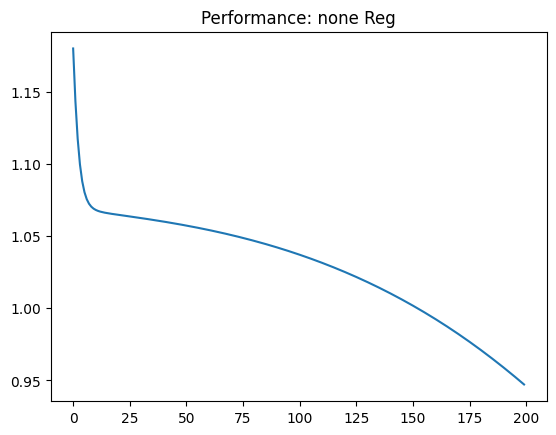

Total Sum of Weights: 11.6030


In [1]:
import math
import random
import matplotlib.pyplot as plt

# --- 1. ACTIVATION FUNCTIONS ---
def sigmoid(x):
    if x > 700: x = 700
    if x < -700: x = -700
    return 1.0 / (1.0 + math.exp(-x))

def sigmoid_derivative(output):
    return output * (1.0 - output)

# --- 2. NETWORK INITIALIZATION ---
def initialize_network(n_inputs, n_hidden, n_outputs):
    network = []
    # Using slightly larger weights to provoke overfitting for demonstration
    hidden_layer = [{'weights': [random.uniform(-1.0, 1.0) for i in range(n_inputs + 1)]} for i in range(n_hidden)]
    network.append(hidden_layer)
    output_layer = [{'weights': [random.uniform(-1.0, 1.0) for i in range(n_hidden + 1)]} for i in range(n_outputs)]
    network.append(output_layer)
    return network

# --- 3. PROPAGATION ---
def forward_propagate(network, row):
    inputs = row
    for layer in network:
        new_inputs = []
        for neuron in layer:
            activation = neuron['weights'][-1]
            for i in range(len(inputs)):
                activation += neuron['weights'][i] * inputs[i]
            neuron['output'] = sigmoid(activation)
            new_inputs.append(neuron['output'])
        inputs = new_inputs
    return inputs

def backward_propagate_error(network, expected):
    for i in reversed(range(len(network))):
        layer = network[i]
        errors = []
        if i != len(network) - 1:
            for j in range(len(layer)):
                error = 0.0
                for neuron in network[i + 1]:
                    error += (neuron['weights'][j] * neuron['delta'])
                errors.append(error)
        else:
            for j in range(len(layer)):
                neuron = layer[j]
                errors.append(expected[j] - neuron['output'])
        for j in range(len(layer)):
            neuron = layer[j]
            neuron['delta'] = errors[j] * sigmoid_derivative(neuron['output'])

# --- 4. REGULARIZATION (THE EXPERIMENT) ---
def update_weights(network, row, l_rate, reg_type='none', lambda_val=0.01):
    for i in range(len(network)):
        inputs = row[:-1]
        if i != 0:
            inputs = [neuron['output'] for neuron in network[i - 1]]
        for neuron in network[i]:
            for j in range(len(inputs)):
                gradient = neuron['delta'] * inputs[j]

                # Apply Regularization Penalty
                penalty = 0.0
                if reg_type == 'l1': # Lasso
                    penalty = lambda_val * (1 if neuron['weights'][j] > 0 else -1)
                elif reg_type == 'l2': # Ridge
                    penalty = lambda_val * neuron['weights'][j]

                # Update: w = w + (learning_rate * gradient) - (learning_rate * penalty)
                neuron['weights'][j] += l_rate * gradient
                neuron['weights'][j] -= l_rate * penalty

            # Bias update (No regularization usually applied to bias)
            neuron['weights'][-1] += l_rate * neuron['delta']

# --- 5. TRAINING LOOP ---
def train_network(network, dataset, l_rate, n_epoch, reg_type, lambda_val):
    history = []
    for epoch in range(n_epoch):
        sum_error = 0
        for row in dataset:
            forward_propagate(network, row[:-1])
            expected = [row[-1]]
            backward_propagate_error(network, expected)
            update_weights(network, row, l_rate, reg_type, lambda_val)
            sum_error += (expected[0] - network[-1][0]['output'])**2
        history.append(sum_error)
    return history

# --- 6. EXECUTION BLOCK ---
dataset = [[0,0,0], [0,1,1], [1,0,1], [1,1,0]]
network = initialize_network(2, 4, 1)

# Modify these lines for different variations
reg_choice = 'none'   # Change to 'l1' or 'l2'
penalty_strength = 0.01

print(f"Training with {reg_choice} Regularization...")
errors = train_network(network, dataset, 0.5, 200, reg_choice, penalty_strength)

plt.plot(errors)
plt.title(f'Performance: {reg_choice} Reg')
plt.show()

# Helper to check weight sizes
total_weight = sum(abs(w) for layer in network for n in layer for w in n['weights'][:-1])
print(f"Total Sum of Weights: {total_weight:.4f}")

Training with none Regularization...


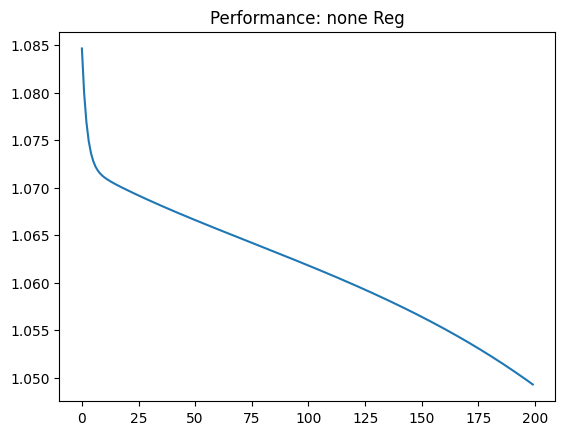

Total Sum of Weights: 8.0626


In [2]:
# penalty strength = 0.0 reg_choice = none
import math
import random
import matplotlib.pyplot as plt

# --- 1. ACTIVATION FUNCTIONS ---
def sigmoid(x):
    if x > 700: x = 700
    if x < -700: x = -700
    return 1.0 / (1.0 + math.exp(-x))

def sigmoid_derivative(output):
    return output * (1.0 - output)

# --- 2. NETWORK INITIALIZATION ---
def initialize_network(n_inputs, n_hidden, n_outputs):
    network = []
    # Using slightly larger weights to provoke overfitting for demonstration
    hidden_layer = [{'weights': [random.uniform(-1.0, 1.0) for i in range(n_inputs + 1)]} for i in range(n_hidden)]
    network.append(hidden_layer)
    output_layer = [{'weights': [random.uniform(-1.0, 1.0) for i in range(n_hidden + 1)]} for i in range(n_outputs)]
    network.append(output_layer)
    return network

# --- 3. PROPAGATION ---
def forward_propagate(network, row):
    inputs = row
    for layer in network:
        new_inputs = []
        for neuron in layer:
            activation = neuron['weights'][-1]
            for i in range(len(inputs)):
                activation += neuron['weights'][i] * inputs[i]
            neuron['output'] = sigmoid(activation)
            new_inputs.append(neuron['output'])
        inputs = new_inputs
    return inputs

def backward_propagate_error(network, expected):
    for i in reversed(range(len(network))):
        layer = network[i]
        errors = []
        if i != len(network) - 1:
            for j in range(len(layer)):
                error = 0.0
                for neuron in network[i + 1]:
                    error += (neuron['weights'][j] * neuron['delta'])
                errors.append(error)
        else:
            for j in range(len(layer)):
                neuron = layer[j]
                errors.append(expected[j] - neuron['output'])
        for j in range(len(layer)):
            neuron = layer[j]
            neuron['delta'] = errors[j] * sigmoid_derivative(neuron['output'])

# --- 4. REGULARIZATION (THE EXPERIMENT) ---
def update_weights(network, row, l_rate, reg_type='none', lambda_val=0.01):
    for i in range(len(network)):
        inputs = row[:-1]
        if i != 0:
            inputs = [neuron['output'] for neuron in network[i - 1]]
        for neuron in network[i]:
            for j in range(len(inputs)):
                gradient = neuron['delta'] * inputs[j]

                # Apply Regularization Penalty
                penalty = 0.0
                if reg_type == 'l1': # Lasso
                    penalty = lambda_val * (1 if neuron['weights'][j] > 0 else -1)
                elif reg_type == 'l2': # Ridge
                    penalty = lambda_val * neuron['weights'][j]

                # Update: w = w + (learning_rate * gradient) - (learning_rate * penalty)
                neuron['weights'][j] += l_rate * gradient
                neuron['weights'][j] -= l_rate * penalty

            # Bias update (No regularization usually applied to bias)
            neuron['weights'][-1] += l_rate * neuron['delta']

# --- 5. TRAINING LOOP ---
def train_network(network, dataset, l_rate, n_epoch, reg_type, lambda_val):
    history = []
    for epoch in range(n_epoch):
        sum_error = 0
        for row in dataset:
            forward_propagate(network, row[:-1])
            expected = [row[-1]]
            backward_propagate_error(network, expected)
            update_weights(network, row, l_rate, reg_type, lambda_val)
            sum_error += (expected[0] - network[-1][0]['output'])**2
        history.append(sum_error)
    return history

# --- 6. EXECUTION BLOCK ---
dataset = [[0,0,0], [0,1,1], [1,0,1], [1,1,0]]
network = initialize_network(2, 4, 1)

# Modify these lines for different variations
reg_choice = 'none'   # Change to 'l1' or 'l2'
penalty_strength = 0.0

print(f"Training with {reg_choice} Regularization...")
errors = train_network(network, dataset, 0.5, 200, reg_choice, penalty_strength)

plt.plot(errors)
plt.title(f'Performance: {reg_choice} Reg')
plt.show()

# Helper to check weight sizes
total_weight = sum(abs(w) for layer in network for n in layer for w in n['weights'][:-1])
print(f"Total Sum of Weights: {total_weight:.4f}")

Training with l2 Regularization...


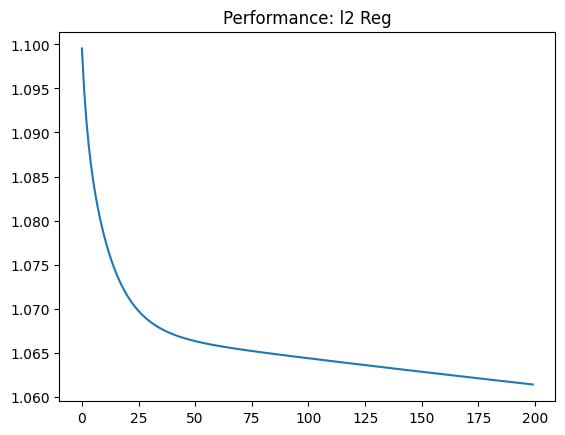

Total Sum of Weights: 0.0609


In [3]:
# reg_choice = 'l2'
# penalty_strength = 0.05
import math
import random
import matplotlib.pyplot as plt

# --- 1. ACTIVATION FUNCTIONS ---
def sigmoid(x):
    if x > 700: x = 700
    if x < -700: x = -700
    return 1.0 / (1.0 + math.exp(-x))

def sigmoid_derivative(output):
    return output * (1.0 - output)

# --- 2. NETWORK INITIALIZATION ---
def initialize_network(n_inputs, n_hidden, n_outputs):
    network = []
    # Using slightly larger weights to provoke overfitting for demonstration
    hidden_layer = [{'weights': [random.uniform(-1.0, 1.0) for i in range(n_inputs + 1)]} for i in range(n_hidden)]
    network.append(hidden_layer)
    output_layer = [{'weights': [random.uniform(-1.0, 1.0) for i in range(n_hidden + 1)]} for i in range(n_outputs)]
    network.append(output_layer)
    return network

# --- 3. PROPAGATION ---
def forward_propagate(network, row):
    inputs = row
    for layer in network:
        new_inputs = []
        for neuron in layer:
            activation = neuron['weights'][-1]
            for i in range(len(inputs)):
                activation += neuron['weights'][i] * inputs[i]
            neuron['output'] = sigmoid(activation)
            new_inputs.append(neuron['output'])
        inputs = new_inputs
    return inputs

def backward_propagate_error(network, expected):
    for i in reversed(range(len(network))):
        layer = network[i]
        errors = []
        if i != len(network) - 1:
            for j in range(len(layer)):
                error = 0.0
                for neuron in network[i + 1]:
                    error += (neuron['weights'][j] * neuron['delta'])
                errors.append(error)
        else:
            for j in range(len(layer)):
                neuron = layer[j]
                errors.append(expected[j] - neuron['output'])
        for j in range(len(layer)):
            neuron = layer[j]
            neuron['delta'] = errors[j] * sigmoid_derivative(neuron['output'])

# --- 4. REGULARIZATION (THE EXPERIMENT) ---
def update_weights(network, row, l_rate, reg_type='none', lambda_val=0.01):
    for i in range(len(network)):
        inputs = row[:-1]
        if i != 0:
            inputs = [neuron['output'] for neuron in network[i - 1]]
        for neuron in network[i]:
            for j in range(len(inputs)):
                gradient = neuron['delta'] * inputs[j]

                # Apply Regularization Penalty
                penalty = 0.0
                if reg_type == 'l1': # Lasso
                    penalty = lambda_val * (1 if neuron['weights'][j] > 0 else -1)
                elif reg_type == 'l2': # Ridge
                    penalty = lambda_val * neuron['weights'][j]

                # Update: w = w + (learning_rate * gradient) - (learning_rate * penalty)
                neuron['weights'][j] += l_rate * gradient
                neuron['weights'][j] -= l_rate * penalty

            # Bias update (No regularization usually applied to bias)
            neuron['weights'][-1] += l_rate * neuron['delta']

# --- 5. TRAINING LOOP ---
def train_network(network, dataset, l_rate, n_epoch, reg_type, lambda_val):
    history = []
    for epoch in range(n_epoch):
        sum_error = 0
        for row in dataset:
            forward_propagate(network, row[:-1])
            expected = [row[-1]]
            backward_propagate_error(network, expected)
            update_weights(network, row, l_rate, reg_type, lambda_val)
            sum_error += (expected[0] - network[-1][0]['output'])**2
        history.append(sum_error)
    return history

# --- 6. EXECUTION BLOCK ---
dataset = [[0,0,0], [0,1,1], [1,0,1], [1,1,0]]
network = initialize_network(2, 4, 1)

# Modify these lines for different variations
reg_choice = 'l2'   # Change to 'l1' or 'l2'
penalty_strength = 0.05

print(f"Training with {reg_choice} Regularization...")
errors = train_network(network, dataset, 0.5, 200, reg_choice, penalty_strength)

plt.plot(errors)
plt.title(f'Performance: {reg_choice} Reg')
plt.show()

# Helper to check weight sizes
total_weight = sum(abs(w) for layer in network for n in layer for w in n['weights'][:-1])
print(f"Total Sum of Weights: {total_weight:.4f}")

Training with l1 Regularization...


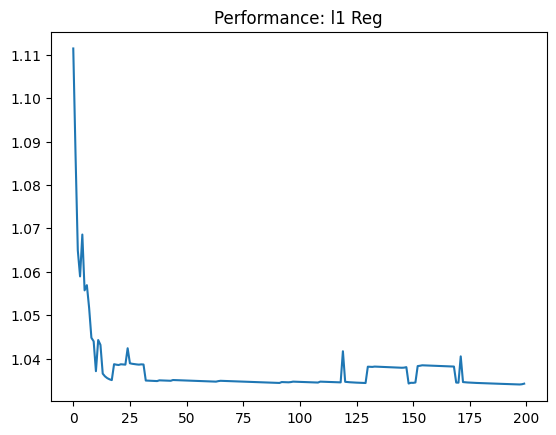

Total Sum of Weights: 0.2317


In [4]:
# reg_choice = 'l1'
# penalty_strength = 0.05
import math
import random
import matplotlib.pyplot as plt

# --- 1. ACTIVATION FUNCTIONS ---
def sigmoid(x):
    if x > 700: x = 700
    if x < -700: x = -700
    return 1.0 / (1.0 + math.exp(-x))

def sigmoid_derivative(output):
    return output * (1.0 - output)

# --- 2. NETWORK INITIALIZATION ---
def initialize_network(n_inputs, n_hidden, n_outputs):
    network = []
    # Using slightly larger weights to provoke overfitting for demonstration
    hidden_layer = [{'weights': [random.uniform(-1.0, 1.0) for i in range(n_inputs + 1)]} for i in range(n_hidden)]
    network.append(hidden_layer)
    output_layer = [{'weights': [random.uniform(-1.0, 1.0) for i in range(n_hidden + 1)]} for i in range(n_outputs)]
    network.append(output_layer)
    return network

# --- 3. PROPAGATION ---
def forward_propagate(network, row):
    inputs = row
    for layer in network:
        new_inputs = []
        for neuron in layer:
            activation = neuron['weights'][-1]
            for i in range(len(inputs)):
                activation += neuron['weights'][i] * inputs[i]
            neuron['output'] = sigmoid(activation)
            new_inputs.append(neuron['output'])
        inputs = new_inputs
    return inputs

def backward_propagate_error(network, expected):
    for i in reversed(range(len(network))):
        layer = network[i]
        errors = []
        if i != len(network) - 1:
            for j in range(len(layer)):
                error = 0.0
                for neuron in network[i + 1]:
                    error += (neuron['weights'][j] * neuron['delta'])
                errors.append(error)
        else:
            for j in range(len(layer)):
                neuron = layer[j]
                errors.append(expected[j] - neuron['output'])
        for j in range(len(layer)):
            neuron = layer[j]
            neuron['delta'] = errors[j] * sigmoid_derivative(neuron['output'])

# --- 4. REGULARIZATION (THE EXPERIMENT) ---
def update_weights(network, row, l_rate, reg_type='none', lambda_val=0.01):
    for i in range(len(network)):
        inputs = row[:-1]
        if i != 0:
            inputs = [neuron['output'] for neuron in network[i - 1]]
        for neuron in network[i]:
            for j in range(len(inputs)):
                gradient = neuron['delta'] * inputs[j]

                # Apply Regularization Penalty
                penalty = 0.0
                if reg_type == 'l1': # Lasso
                    penalty = lambda_val * (1 if neuron['weights'][j] > 0 else -1)
                elif reg_type == 'l2': # Ridge
                    penalty = lambda_val * neuron['weights'][j]

                # Update: w = w + (learning_rate * gradient) - (learning_rate * penalty)
                neuron['weights'][j] += l_rate * gradient
                neuron['weights'][j] -= l_rate * penalty

            # Bias update (No regularization usually applied to bias)
            neuron['weights'][-1] += l_rate * neuron['delta']

# --- 5. TRAINING LOOP ---
def train_network(network, dataset, l_rate, n_epoch, reg_type, lambda_val):
    history = []
    for epoch in range(n_epoch):
        sum_error = 0
        for row in dataset:
            forward_propagate(network, row[:-1])
            expected = [row[-1]]
            backward_propagate_error(network, expected)
            update_weights(network, row, l_rate, reg_type, lambda_val)
            sum_error += (expected[0] - network[-1][0]['output'])**2
        history.append(sum_error)
    return history

# --- 6. EXECUTION BLOCK ---
dataset = [[0,0,0], [0,1,1], [1,0,1], [1,1,0]]
network = initialize_network(2, 4, 1)

# Modify these lines for different variations
reg_choice = 'l1'   # Change to 'l1' or 'l2'
penalty_strength = 0.05

print(f"Training with {reg_choice} Regularization...")
errors = train_network(network, dataset, 0.5, 200, reg_choice, penalty_strength)

plt.plot(errors)
plt.title(f'Performance: {reg_choice} Reg')
plt.show()

# Helper to check weight sizes
total_weight = sum(abs(w) for layer in network for n in layer for w in n['weights'][:-1])
print(f"Total Sum of Weights: {total_weight:.4f}")